In [2]:
# Cell 1 — Imports and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from sklearn.ensemble import IsolationForest
from scipy import stats
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

load_dotenv('../.env')

DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER','postgres')}:"
    f"{os.getenv('DB_PASSWORD','postgres123')}@"
    f"{os.getenv('DB_HOST','localhost')}:"
    f"{os.getenv('DB_PORT','5433')}/"
    f"{os.getenv('DB_NAME','nifty100')}"
)
engine = create_engine(DATABASE_URL)

# Load P&L data
df = pd.read_sql("""
    SELECT fpl.symbol, fpl.sales, fpl.net_profit,
           fpl.operating_profit, fpl.opm_pct, fpl.interest,
           dy.fiscal_year, dy.year_label,
           dc.company_name, ds.sector_name
    FROM fact_profit_loss fpl
    JOIN dim_year dy ON fpl.year_id = dy.year_id
    JOIN dim_company dc ON fpl.symbol = dc.symbol
    LEFT JOIN dim_sector ds ON dc.sector_id = ds.sector_id
    WHERE dy.is_ttm = FALSE
    ORDER BY fpl.symbol, dy.sort_order
""", engine)

print(f"Loaded {len(df)} rows for {df['symbol'].nunique()} companies")
print(f"Columns: {list(df.columns)}")

Loaded 1073 rows for 92 companies
Columns: ['symbol', 'sales', 'net_profit', 'operating_profit', 'opm_pct', 'interest', 'fiscal_year', 'year_label', 'company_name', 'sector_name']


In [3]:
# Cell 2 — Z-Score Anomaly Detection
# Flag any year where |Z-score| > 2.5 as an anomaly

print("Running Z-Score Anomaly Detection...")

metrics = ["sales", "net_profit", "operating_profit"]
anomalies_zscore = []

for symbol in df["symbol"].unique():
    company_data = df[df["symbol"] == symbol].copy()
    
    for metric in metrics:
        values = company_data[metric].dropna()
        if len(values) < 4:
            continue
            
        z_scores = np.abs(stats.zscore(values))
        
        for idx, (z, row) in enumerate(zip(z_scores, company_data.itertuples())):
            if z > 2.5:
                anomalies_zscore.append({
                    "symbol"      : symbol,
                    "company_name": row.company_name,
                    "sector_name" : row.sector_name,
                    "fiscal_year" : row.fiscal_year,
                    "year_label"  : row.year_label,
                    "metric"      : metric,
                    "value"       : getattr(row, metric),
                    "z_score"     : round(z, 2),
                    "method"      : "Z-Score",
                })

df_anomalies_z = pd.DataFrame(anomalies_zscore)
print(f"Z-Score anomalies found: {len(df_anomalies_z)}")
print(f"Companies with anomalies: {df_anomalies_z['symbol'].nunique()}")
print("\nTop 10 anomalies by Z-score:")
print(df_anomalies_z.nlargest(10, "z_score")[
    ["symbol", "fiscal_year", "metric", "value", "z_score"]
].to_string(index=False))

Running Z-Score Anomaly Detection...
Z-Score anomalies found: 33
Companies with anomalies: 22

Top 10 anomalies by Z-score:
    symbol  fiscal_year           metric    value  z_score
    NAUKRI         2022       net_profit  12882.0     3.29
BAJAJHLDNG         2024 operating_profit   1562.0     3.21
     TRENT         2024       net_profit   1477.0     3.15
BAJAJHLDNG         2024            sales   1702.0     3.13
  HDFCBANK         2024 operating_profit 174196.0     3.05
      BPCL         2024 operating_profit  44082.0     3.00
BHARTIARTL         2020       net_profit -30664.0     2.84
  AXISBANK         2024       net_profit  24861.0     2.81
BAJAJ-AUTO         2024 operating_profit   8765.0     2.81
 JSWENERGY         2024 operating_profit   5382.0     2.81


In [4]:
# Cell 3 — Isolation Forest Anomaly Detection
print("Running Isolation Forest Anomaly Detection...")

feature_cols = ["sales", "net_profit", "operating_profit"]
anomalies_if = []

for symbol in df["symbol"].unique():
    company_data = df[df["symbol"] == symbol].copy()
    data = company_data[feature_cols].dropna()
    
    if len(data) < 5:
        continue
    
    # Fit Isolation Forest
    iso = IsolationForest(contamination=0.15, random_state=42)
    preds = iso.fit_predict(data)
    scores = iso.score_samples(data)
    
    # -1 means anomaly
    anomaly_mask = preds == -1
    anomaly_rows = company_data.loc[data.index[anomaly_mask]]
    
    for _, row in anomaly_rows.iterrows():
        anomalies_if.append({
            "symbol"      : symbol,
            "company_name": row["company_name"],
            "sector_name" : row["sector_name"],
            "fiscal_year" : row["fiscal_year"],
            "year_label"  : row["year_label"],
            "sales"       : row["sales"],
            "net_profit"  : row["net_profit"],
            "method"      : "IsolationForest",
        })

df_anomalies_if = pd.DataFrame(anomalies_if)
print(f"Isolation Forest anomalies found: {len(df_anomalies_if)}")
print(f"Companies with anomalies: {df_anomalies_if['symbol'].nunique()}")

# ── Compare both methods ──
z_symbols = set(df_anomalies_z["symbol"].unique())
if_symbols = set(df_anomalies_if["symbol"].unique())
both = z_symbols & if_symbols

print(f"\nAgreement between methods:")
print(f"Z-Score only:        {len(z_symbols - if_symbols)} companies")
print(f"Isolation Forest only: {len(if_symbols - z_symbols)} companies")
print(f"Both methods agree:  {len(both)} companies")
print(f"Companies flagged by both: {sorted(both)}")

Running Isolation Forest Anomaly Detection...
Isolation Forest anomalies found: 178
Companies with anomalies: 90

Agreement between methods:
Z-Score only:        0 companies
Isolation Forest only: 68 companies
Both methods agree:  22 companies
Companies flagged by both: ['ADANIENT', 'ADANIPOWER', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJHLDNG', 'BHARTIARTL', 'BHEL', 'BPCL', 'CIPLA', 'DIVISLAB', 'DLF', 'DRREDDY', 'GODREJCP', 'HDFCBANK', 'JSWENERGY', 'JSWSTEEL', 'MARUTI', 'NAUKRI', 'TATAMOTORS', 'TATASTEEL', 'TRENT', 'TVSMOTOR']


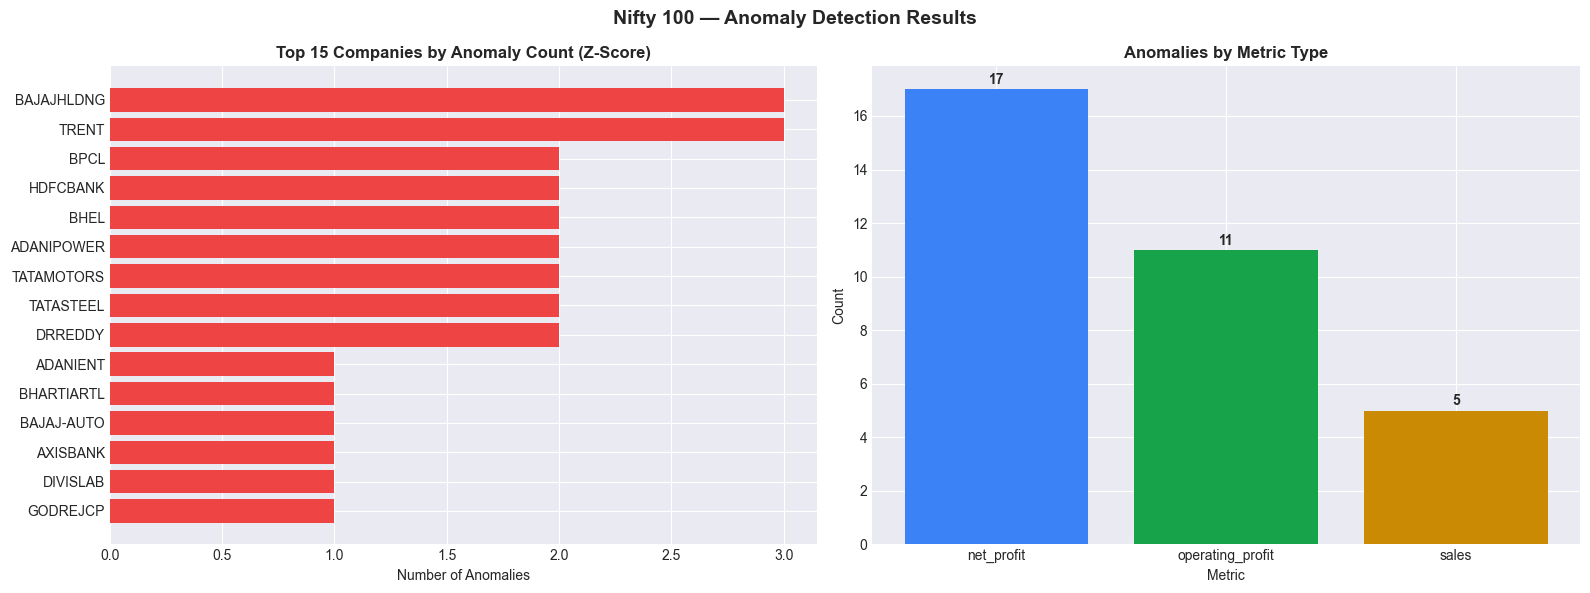

Saved 33 anomalies to PostgreSQL
HIGH severity:   5
MEDIUM severity: 10
LOW severity:    18


In [5]:
# Cell 4 — Visualize Anomalies and Save to PostgreSQL

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Nifty 100 — Anomaly Detection Results", fontsize=14, fontweight='bold')

# ── Chart 1: Anomalies by Company (Z-Score) ──
anomaly_counts = df_anomalies_z.groupby("symbol").size().sort_values(ascending=False).head(15)
axes[0].barh(anomaly_counts.index[::-1], anomaly_counts.values[::-1], color="#ef4444")
axes[0].set_title("Top 15 Companies by Anomaly Count (Z-Score)", fontweight='bold')
axes[0].set_xlabel("Number of Anomalies")

# ── Chart 2: Anomalies by Metric ──
metric_counts = df_anomalies_z["metric"].value_counts()
colors = ["#3b82f6", "#16a34a", "#ca8a04"]
axes[1].bar(metric_counts.index, metric_counts.values, color=colors)
axes[1].set_title("Anomalies by Metric Type", fontweight='bold')
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("Count")
for i, (idx, val) in enumerate(zip(metric_counts.index, metric_counts.values)):
    axes[1].text(i, val + 0.2, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/clean/anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save anomalies to PostgreSQL ──
# First create the table if it doesn't exist
with engine.connect() as conn:
    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS fact_anomalies (
            id          SERIAL PRIMARY KEY,
            symbol      VARCHAR(20),
            company_name VARCHAR(200),
            sector_name VARCHAR(100),
            fiscal_year INT,
            year_label  VARCHAR(20),
            metric      VARCHAR(50),
            value       NUMERIC(20,2),
            z_score     NUMERIC(10,2),
            method      VARCHAR(30),
            severity    VARCHAR(10),
            reviewed    BOOLEAN DEFAULT FALSE,
            detected_at TIMESTAMP DEFAULT NOW()
        )
    """))
    conn.commit()

# Add severity
df_anomalies_z["severity"] = df_anomalies_z["z_score"].apply(
    lambda z: "HIGH" if z > 3.0 else "MEDIUM" if z > 2.7 else "LOW"
)

# Save
count = 0
with engine.connect() as conn:
    for _, row in df_anomalies_z.iterrows():
        conn.execute(text("""
            INSERT INTO fact_anomalies 
                (symbol, company_name, sector_name, fiscal_year, 
                 year_label, metric, value, z_score, method, severity)
            VALUES 
                (:symbol, :company_name, :sector_name, :fiscal_year,
                 :year_label, :metric, :value, :z_score, :method, :severity)
            ON CONFLICT DO NOTHING
        """), {
            "symbol"      : row["symbol"],
            "company_name": row["company_name"],
            "sector_name" : row["sector_name"],
            "fiscal_year" : int(row["fiscal_year"]),
            "year_label"  : row["year_label"],
            "metric"      : row["metric"],
            "value"       : float(row["value"]) if not pd.isna(row["value"]) else None,
            "z_score"     : float(row["z_score"]),
            "method"      : row["method"],
            "severity"    : row["severity"],
        })
        count += 1
    conn.commit()

print(f"Saved {count} anomalies to PostgreSQL")
print(f"HIGH severity:   {(df_anomalies_z['severity']=='HIGH').sum()}")
print(f"MEDIUM severity: {(df_anomalies_z['severity']=='MEDIUM').sum()}")
print(f"LOW severity:    {(df_anomalies_z['severity']=='LOW').sum()}")